In [ ]:
import pandas as pd

# Define your data
data = {
    'image_id': [f"image{i}.png" for i in range(1, 40)],  # Generate image names from 1.svg.png to 39.svg.png
    'text': [
        '𐰀', '𐰃', '𐰅', '𐰆', '𐰇',
        '𐰉', '𐰑', '𐰍', '𐰞', '𐰣',
        '𐰺', '𐰽', '𐱃', '𐰖', '𐰴',
        '𐰸', '𐰋', '𐰓', '𐰏', '𐰠',
        '𐰤', '𐰼', '𐰾', '𐱅', '𐰘',
        '𐰚', '𐰜', '𐰲', '𐰢', '𐰯',
        '𐱁', '𐰔', '𐰭', '𐰱', '𐰶',
        '𐰨', '𐰪', '𐰡', '𐰦'
    ],
    'transliteration': [
        'a', 'ï/ı', 'e', 'o', 'ö',
        'b¹', 'd¹', 'γ/g¹', 'l¹', 'n¹',
        'r¹', 's¹', 't¹', 'y¹/j¹', 'q',
        'oq', 'b²', 'd²', 'g/g²', 'l²',
        'n²', 'r²', 's²', 't²', 'y²/j²',
        'k', 'ök', 'č', 'm', 'p',
        'š', 'z', 'ñ/ň/ŋ', 'ič', 'ıq',
        '-nč', '-nj/ny/ñ', '-lt', '-nt'
    ],
    'ipa': [
        '/ɑ/', '/ɯ/', '/e/', '/o/', '/ø/',
        '/b/', '/d/', '/ɢ/', '/l/', '/n/',
        '/r/', '/s/', '/t/', '/j/', '/q/',
        '/oq/', '/b/', '/d/', '/ɡ/', '/l/',
        '/n/', '/r/', '/s/', '/t/', '/j/',
        '/k/', '/øk/', '/tʃ/', '/m/', '/p/',
        '/ʃ/', '/z/', '/ŋ/', '/itʃ/', '/ɯq/',
        '/ntʃ/', '/ɲ/', '/lt/', '/nt/'
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save DataFrame to CSV
csv_file_path = 'old_turkic_script.csv'
df.to_csv(csv_file_path, index=False)

print(f"CSV file has been created at {csv_file_path}")


CSV file has been created at old_turkic_script.csv


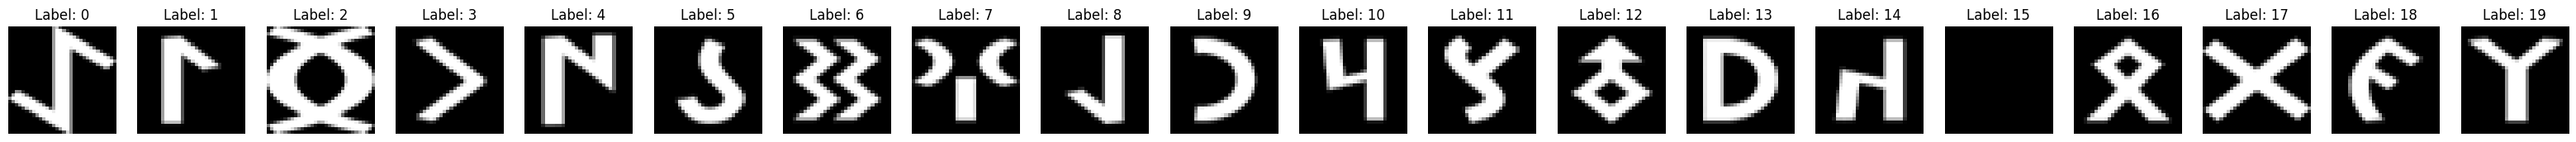

In [ ]:
import matplotlib.pyplot as plt

def show_images_with_labels(images, labels, num_images=20):
    fig, axes = plt.subplots(1, num_images, figsize=(2 * num_images, 3))
    for i, ax in enumerate(axes):
        # Assuming images are normalized and in shape (32, 32, 1)
        ax.imshow(images[i].reshape(32, 32), cmap='gray')
        label = np.argmax(labels[i])  # Assuming labels are one-hot encoded
        ax.set_title(f'Label: {label}')
        ax.axis('off')
    plt.show()

# Assuming you have 'images' and 'labels' loaded and you want to show the first 10 images
show_images_with_labels(images, labels, num_images=20)


Epoch 1/20
11/11 [==============================] - 2s 72ms/step - loss: 3.6325 - accuracy: 0.0525 - val_loss: 3.5647 - val_accuracy: 0.0930
Epoch 2/20
11/11 [==============================] - 1s 51ms/step - loss: 3.1455 - accuracy: 0.1749 - val_loss: 2.8905 - val_accuracy: 0.2326
Epoch 3/20
11/11 [==============================] - 1s 51ms/step - loss: 1.9741 - accuracy: 0.5102 - val_loss: 1.6777 - val_accuracy: 0.5000
Epoch 4/20
11/11 [==============================] - 1s 50ms/step - loss: 1.0990 - accuracy: 0.6968 - val_loss: 1.2312 - val_accuracy: 0.6744
Epoch 5/20
11/11 [==============================] - 1s 49ms/step - loss: 0.6516 - accuracy: 0.8076 - val_loss: 1.0375 - val_accuracy: 0.7674
Epoch 6/20
11/11 [==============================] - 1s 48ms/step - loss: 0.4539 - accuracy: 0.8601 - val_loss: 0.6796 - val_accuracy: 0.8023
Epoch 7/20
11/11 [==============================] - 1s 48ms/step - loss: 0.2144 - accuracy: 0.9388 - val_loss: 0.6099 - val_accuracy: 0.7907
Epoch 8/20
11

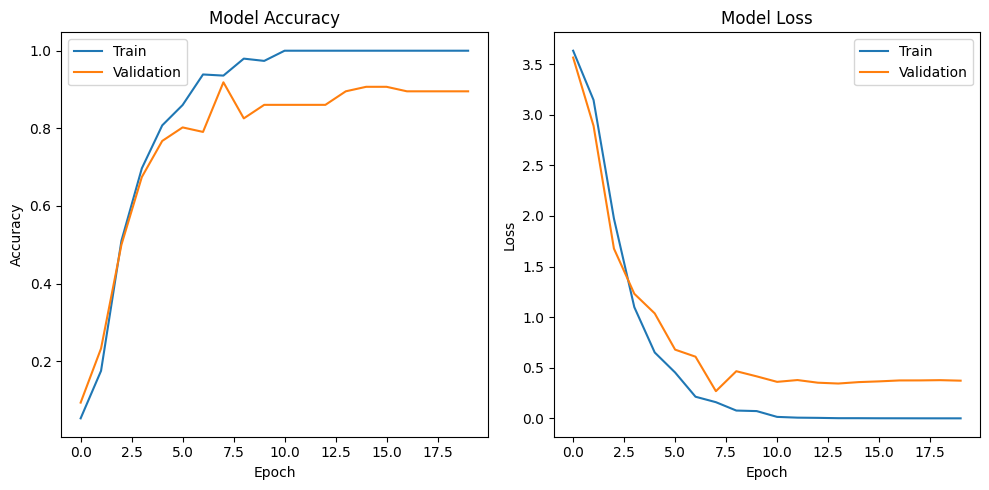

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
from tensorflow.keras.utils import to_categorical

def load_image(image_dir, filename):
    image_path = os.path.join(image_dir, filename)
    try:
        img = Image.open(image_path)  # Ensure it's in RGB
        img = img.resize((32, 32))
        img_array = np.array(img)
        green_channel = img_array[:, :, 1]  # Extract the green channel
        green_channel = green_channel / 255.0  # Normalize pixel values to [0, 1]
        return green_channel.reshape(32, 32, 1)
    except Exception as e:
        print(f"Error loading image {image_path}: {str(e)}")
        return None

def load_dataset(csv_path, image_dir):
    df = pd.read_csv(csv_path)
    images = []
    labels = []

    unique_texts = df['text'].unique()
    label_to_index = {text: idx for idx, text in enumerate(unique_texts)}

    for _, row in df.iterrows():
        filename = row['image_id']
        label = label_to_index[row['text']]  # Convert text label to integer
        image = load_image(image_dir, filename)
        if image is not None:
            images.append(image)
            labels.append(label)
        else:
            print(f"Skipping image {filename} due to loading issues.")

    return np.array(images), np.array(labels)

def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

image_dir = 'ocr_8'
csv_path = 'old_turkic_script.csv'
images, labels = load_dataset(csv_path, image_dir)
labels = to_categorical(labels)  # Convert labels to one-hot encoding

# Data Augmentation configuration
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Prepare augmented data generator
augmented_images, augmented_labels = [], []
for x, y in zip(images, labels):
    x = x.reshape((1,) + x.shape)  # Reshape image to (1, 32, 32, 1)
    i = 0
    for batch in datagen.flow(x, batch_size=1):
        augmented_images.append(batch[0])
        augmented_labels.append(y)
        i += 1
        if i >= 10:  # Augment each image 10 times
            break

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# Combine original and augmented data
final_images = np.concatenate([images, augmented_images])
final_labels = np.concatenate([labels, augmented_labels])

# Splitting dataset into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split(final_images, final_labels, test_size=0.2, random_state=42)

num_classes = train_labels.shape[1]
input_shape = train_images[0].shape

# Initialize and compile the CNN model
model = build_cnn_model(input_shape, num_classes)

# Fit the model on the training data
history = model.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels), batch_size=32)

# Plot training and validation accuracy and loss
plot_history(history)

def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


1/1 [==============================] - 0s 41ms/step


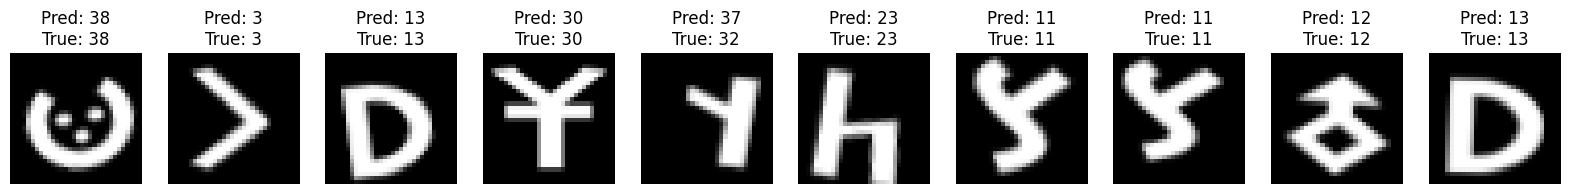

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions(images, true_labels, model, num_examples=10):
    predictions = model.predict(images[:num_examples])
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels[:num_examples], axis=1)

    fig, axes = plt.subplots(1, num_examples, figsize=(2 * num_examples, 4))
    for i in range(num_examples):
        ax = axes[i]
        ax.imshow(images[i].reshape(32, 32), cmap='gray')  # Assuming images are single-channel
        ax.set_title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
        ax.axis('off')
    plt.show()

# Assuming `val_images` and `val_labels` are your validation datasets
# and `model` is your trained model
display_predictions(val_images, val_labels, model, num_examples=10)
